# Q1 — Radon Transform (Shepp-Logan)
Implementations: myXrayIntegration, myXrayCTRadonTransform and comparisons.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from scipy.interpolate import RegularGridInterpolator

In [3]:
# generate phantom and set coordinate frame
N = 128
phantom = shepp_logan_phantom()
f = resize(phantom, (N, N), order=1, mode='constant', anti_aliasing=True)
ys = np.arange(N) - (N-1)/2.0
xs = np.arange(N) - (N-1)/2.0

In [4]:
def myXrayIntegration(img, t, theta_deg, ds=1.0, interp_kind='linear'):
    theta = np.deg2rad(theta_deg)
    x0 = t * np.cos(theta)
    y0 = t * np.sin(theta)
    max_len = 0.5 * np.sqrt(img.shape[0]**2 + img.shape[1]**2)
    s = np.arange(-max_len, max_len, ds)
    xs = x0 - s * np.sin(theta)
    ys = y0 + s * np.cos(theta)
    interp = RegularGridInterpolator((np.arange(img.shape[0]) - (img.shape[0]-1)/2.0,
                                       np.arange(img.shape[1]) - (img.shape[1]-1)/2.0),
                                       img, method='linear', bounds_error=False, fill_value=0.0)
    pts = np.vstack((ys, xs)).T
    vals = interp(pts)
    return np.sum(vals) * ds

In [5]:
def myXrayCTRadonTransform(img, t_vals, theta_vals, ds=1.0):
    R = np.zeros((len(t_vals), len(theta_vals)))
    for i,t in enumerate(t_vals):
        for j,th in enumerate(theta_vals):
            R[i,j] = myXrayIntegration(img, t, th, ds=ds)
    return R

In [6]:
t_vals = np.arange(-90, 95, 5)
theta_vals = np.arange(0, 180, 5)
ds_list = [0.5, 1.0, 3.0]
radons = {ds: myXrayCTRadonTransform(f, t_vals, theta_vals, ds=ds) for ds in ds_list}

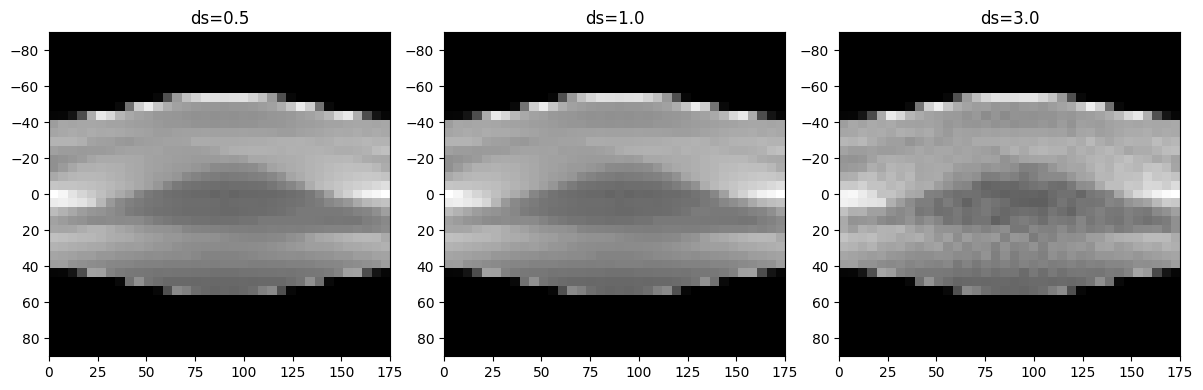

In [7]:
fig, axs = plt.subplots(1,3, figsize=(12,4))
for ax, ds in zip(axs, ds_list):
    ax.imshow(radons[ds], aspect='auto', cmap='gray', extent=[theta_vals[0], theta_vals[-1], t_vals[-1], t_vals[0]])
    ax.set_title(f'ds={ds}')
plt.tight_layout()

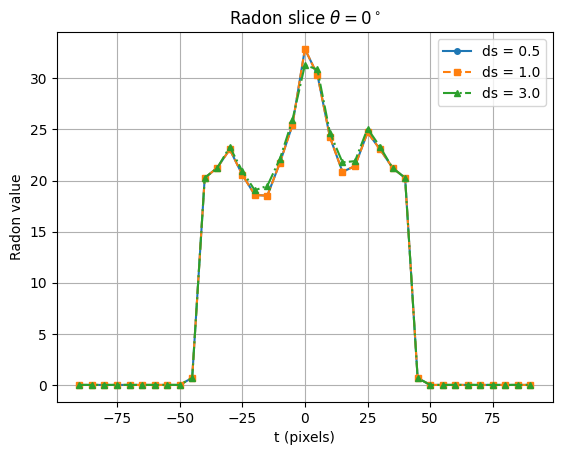

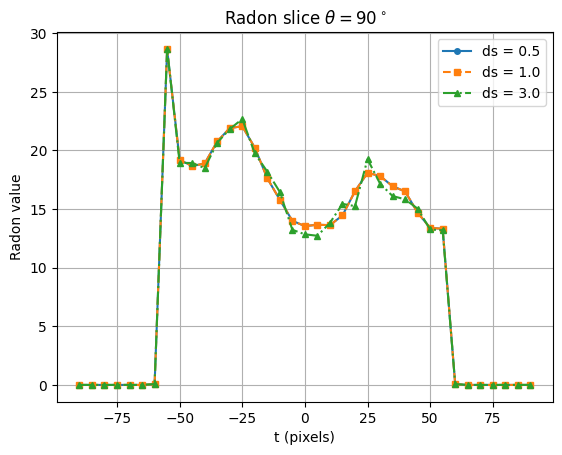

In [8]:
# plot 1D slices for theta=0 and theta=90
markers = {0.5: 'o', 1.0: 's', 3.0: '^'}   # circle, square, triangle
linestyles = {0.5: '-', 1.0: '--', 3.0: '-.'}

for angle in [0, 90]:
    idx = int(angle / 5)
    plt.figure()
    for ds in ds_list:
        plt.plot(
            t_vals,
            radons[ds][:, idx],
            marker=markers[ds],
            linestyle=linestyles[ds],
            markersize=4,
            label=f'ds = {ds}'
        )
    plt.title(f'Radon slice $\\theta = {angle}^\\circ$')
    plt.xlabel('t (pixels)')
    plt.ylabel('Radon value')
    plt.legend()
    plt.grid(True)
    plt.show()

Notes:
- Chosen ds values: 0.5, 1, 3 (smaller ds gives smoother approximation).
- Interpolation: linear via RegularGridInterpolator (balance of accuracy and speed).